# 03 — ResNet50 (Deep Baseline)
**BTL IS54A — Người 3**

Notebook train ResNet50 theo chiến lược Transfer Learning 2 giai đoạn:
- **Phase 1**: Pre-train trên AffectNet (8 lớp cảm xúc, subset 1500/class)
- **Phase 2**: Fine-tune trên Student Engagement Dataset (6 lớp trạng thái)

Mỗi phase gồm 2 stage: Freeze backbone (5 epochs, lr=1e-3) → Unfreeze (10 epochs, lr=1e-5).

**Yêu cầu:** GPU T4 (Colab Free), runtime ~60–70 phút.

---
**Output deliverables:**
- `BTL/weights/resnet50_phase1.h5`
- `BTL/weights/resnet50_phase2.h5`
- `BTL/results/resnet50_metrics.json`
- `BTL/results/resnet50_confusion_matrix.png`

## Cell 1 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install mtcnn -q

import sys
sys.path.append('/content/drive/MyDrive/ProjectBTL/BTL/data')
sys.path.append('/content/drive/MyDrive/ProjectBTL/BTL/models')

import tensorflow as tf
print(f'TF version : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.1 MB/s eta 0:00:00
TF version : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Đường dẫn + Import

In [2]:
AFFECTNET_DIR = '/content/drive/MyDrive/ProjectBTL/AffectNet'
DATA_DIR      = '/content/drive/MyDrive/ProjectBTL/BTL/data'
WEIGHTS_DIR   = '/content/drive/MyDrive/ProjectBTL/BTL/weights'
RESULTS_DIR   = '/content/drive/MyDrive/ProjectBTL/BTL/results'

from preprocess import init_mtcnn
init_mtcnn()

from dataset_affectnet import build_affectnet_dataset
from dataset_student   import build_student_dataset

from resnet50 import (
    build_model,
    freeze_backbone,
    unfreeze_backbone,
    load_phase1_weights_for_phase2,
)
print('Imports OK')

[preprocess] MTCNN khởi tạo thành công.
Imports OK


## Cell 3 — Copy AffectNet sang local SSD (tăng tốc ~50×)

⚠️ **Bắt buộc**: đọc trực tiếp từ Drive → 8s/step (rất chậm).
Copy về `/content/` → ~150ms/step.

In [3]:
import shutil, os

if not os.path.exists('/content/affectnet_local'):
    print('Copying AffectNet → /content/affectnet_local/ ...')
    shutil.copytree(AFFECTNET_DIR, '/content/affectnet_local')
    print('Copy xong!')
else:
    print('Đã tồn tại, bỏ qua copy.')

!du -sh /content/affectnet_local

# Đổi đường dẫn sang local SSD
AFFECTNET_DIR = '/content/affectnet_local'
print(f'\nAFFECTNET_DIR = {AFFECTNET_DIR}')

Copying AffectNet → /content/affectnet_local/ ...
Copy xong!
388M	/content/affectnet_local

AFFECTNET_DIR = /content/affectnet_local


---
# 🚀 PHASE 1 — Pre-train trên AffectNet (8 class)

## Cell 4 — Build dataset

In [4]:
train_ds, class_weights = build_affectnet_dataset(
    split='train', data_dir=AFFECTNET_DIR,
    batch_size=32, subset_per_class=1500
)
test_ds, _ = build_affectnet_dataset(
    split='test', data_dir=AFFECTNET_DIR, batch_size=32
)

print('\nclass_weights:')
for idx, w in sorted(class_weights.items()):
    print(f'  Class {idx}: weight = {w:.4f}')

[dataset_affectnet] train: 11729 ảnh
[dataset_affectnet] test: 14518 ảnh

class_weights:
  Class 0: weight = 0.9774
  Class 1: weight = 0.9774
  Class 2: weight = 1.1929
  Class 3: weight = 0.9774
  Class 4: weight = 0.9774
  Class 5: weight = 0.9774
  Class 6: weight = 0.9774
  Class 7: weight = 0.9774


## Cell 5 — Build model + Freeze backbone

In [5]:
model_p1 = build_model(num_classes=8)
freeze_backbone(model_p1)

model_p1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_p1.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[resnet50] Backbone FROZEN — trainable params: 526,600


Model: "ResNet50_FER_8cls"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 526,600 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Cell 6 — Train Phase 1 (Freeze stage, 5 epochs)

In [6]:
history_p1_freeze = model_p1.fit(
    train_ds, validation_data=test_ds,
    epochs=5, class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)
print(f"\nFreeze stage final val_accuracy: {history_p1_freeze.history['val_accuracy'][-1]:.4f}")

Epoch 1/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 196s 486ms/step - accuracy: 0.2237 - loss: 1.9875 - val_accuracy: 0.2934 - val_loss: 1.8462 - learning_rate: 0.0010
Epoch 2/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 225s 612ms/step - accuracy: 0.2616 - loss: 1.8712 - val_accuracy: 0.2985 - val_loss: 1.8004 - learning_rate: 0.0010
Epoch 3/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 168s 457ms/step - accuracy: 0.2810 - loss: 1.8332 - val_accuracy: 0.3210 - val_loss: 1.7453 - learning_rate: 0.0010
Epoch 4/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 168s 459ms/step - accuracy: 0.2962 - loss: 1.8095 - val_accuracy: 0.3174 - val_loss: 1.7809 - learning_rate: 0.0010
Epoch 5/5
367/367 ━━━━━━━━━━━━━━━━━━━━ 167s 456ms/step - accuracy: 0.2987 - loss: 1.7978 - val_accuracy: 0.3328 - val_loss: 1.7371 - learning_rate: 0.0010

Freeze stage final val_accuracy: 0.3328


## Cell 7 — Unfreeze + Train Phase 1 (10 epochs, lr=1e-5)

In [7]:
unfreeze_backbone(model_p1)
model_p1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_p1_unfreeze = model_p1.fit(
    train_ds, validation_data=test_ds,
    epochs=10, class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'{WEIGHTS_DIR}/resnet50_phase1.h5',
            monitor='val_accuracy', save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)
print(f"\n✅ Phase 1 hoàn thành. Best val_accuracy: "
      f"{max(history_p1_unfreeze.history['val_accuracy']):.4f}")
print(f"Đã lưu weights: {WEIGHTS_DIR}/resnet50_phase1.h5")

[resnet50] Backbone UNFROZEN — trainable params: 24,061,192
Epoch 1/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.2395 - loss: 2.4243
Epoch 1: val_accuracy improved from None to 0.24253, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 337s 751ms/step - accuracy: 0.3028 - loss: 1.9436 - val_accuracy: 0.2425 - val_loss: 2.5439 - learning_rate: 1.0000e-05
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.4390 - loss: 1.4006
Epoch 2: val_accuracy improved from 0.24253 to 0.48175, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 305s 833ms/step - accuracy: 0.4556 - loss: 1.3650 - val_accuracy: 0.4817 - val_loss: 1.8824 - learning_rate: 1.0000e-05
Epoch 3/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.5226 - loss: 1.2236
Epoch 3: val_accuracy improved from 0.48175 to 0.57508, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5



Epoch 3: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 246s 671ms/step - accuracy: 0.5291 - loss: 1.2059 - val_accuracy: 0.5751 - val_loss: 1.4768 - learning_rate: 1.0000e-05
Epoch 4/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.5600 - loss: 1.1226
Epoch 4: val_accuracy improved from 0.57508 to 0.60098, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5



Epoch 4: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 301s 822ms/step - accuracy: 0.5654 - loss: 1.1162 - val_accuracy: 0.6010 - val_loss: 1.4965 - learning_rate: 1.0000e-05
Epoch 5/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.6052 - loss: 1.0316
Epoch 5: val_accuracy improved from 0.60098 to 0.61896, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5


...


Epoch 6: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 245s 666ms/step - accuracy: 0.6389 - loss: 0.9607 - val_accuracy: 0.6331 - val_loss: 1.5048 - learning_rate: 1.0000e-05
Epoch 7/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.6523 - loss: 0.9191
Epoch 7: val_accuracy improved from 0.63308 to 0.64623, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5



Epoch 7: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 250s 681ms/step - accuracy: 0.6527 - loss: 0.9166 - val_accuracy: 0.6462 - val_loss: 1.4562 - learning_rate: 1.0000e-05
Epoch 8/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.6869 - loss: 0.8366
Epoch 8: val_accuracy improved from 0.64623 to 0.65684, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5



Epoch 8: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 246s 670ms/step - accuracy: 0.6838 - loss: 0.8438 - val_accuracy: 0.6568 - val_loss: 1.5119 - learning_rate: 1.0000e-05
Epoch 9/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.7134 - loss: 0.7771
Epoch 9: val_accuracy improved from 0.65684 to 0.65815, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5



Epoch 9: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 302s 824ms/step - accuracy: 0.7099 - loss: 0.7832 - val_accuracy: 0.6581 - val_loss: 1.5011 - learning_rate: 1.0000e-05
Epoch 10/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.7292 - loss: 0.7224
Epoch 10: val_accuracy improved from 0.65815 to 0.66145, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5



Epoch 10: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5
367/367 ━━━━━━━━━━━━━━━━━━━━ 249s 679ms/step - accuracy: 0.7276 - loss: 0.7240 - val_accuracy: 0.6615 - val_loss: 1.5322 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.

✅ Phase 1 hoàn thành. Best val_accuracy: 0.6615
Đã lưu weights: /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.h5


---
# 🎯 PHASE 2 — Fine-tune trên Student Engagement (6 class)

## Cell 8 — Build dataset Phase 2

In [8]:
train_student = build_student_dataset('train', DATA_DIR, batch_size=16)
val_student   = build_student_dataset('val',   DATA_DIR, batch_size=16)
test_student  = build_student_dataset('test',  DATA_DIR, batch_size=16)
print('\n✅ Dataset Phase 2 sẵn sàng (Student Engagement, 6 class)')

[dataset_student] train: 1484 ảnh
label
Looking Away    296
Confused        258
Frustrated      252
Bored           251
Focused         243
Drowsy          184
[dataset_student] val: 318 ảnh
label
Looking Away    64
Confused        56
Frustrated      54
Bored           53
Focused         52
Drowsy          39
[dataset_student] test: 318 ảnh
label
Looking Away    63
Confused        55
Bored           54
Frustrated      54
Focused         52
Drowsy          40

✅ Dataset Phase 2 sẵn sàng (Student Engagement, 6 class)


In [18]:
import os
old = f'{WEIGHTS_DIR}/resnet50_phase1.h5'
if os.path.exists(old):
    os.remove(old)
    print("Xóa xong file hỏng")
else:
    print("File không tồn tại, bỏ qua")

Xóa xong file hỏng


In [19]:
import shutil, os
from google.colab import drive

shutil.copy(
    '/content/weights_local/resnet50_phase1.weights.h5',
    f'{WEIGHTS_DIR}/resnet50_phase1.weights.h5'
)

drive.flush_and_unmount()
drive.mount('/content/drive')

print("Done")
!ls -la {WEIGHTS_DIR}/

Mounted at /content/drive
Done
total 295946
-rw------- 1 root root  13443752 Jun  9 04:04 mobilenetv3_phase1.h5
-rw------- 1 root root      1216 May 22 08:20 README.md
-rw------- 1 root root 289602408 Jun  9 05:12 resnet50_phase1.weights.h5


## Cell 9 — Build model Phase 2 + Load weights từ Phase 1

In [20]:
model_p2 = build_model(num_classes=6)
load_phase1_weights_for_phase2(
    model_p2, f'{WEIGHTS_DIR}/resnet50_phase1.weights.h5'
)

freeze_backbone(model_p2)
model_p2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_p2.summary()

[resnet50] Loaded Phase 1 weights từ /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase1.weights.h5
[resnet50]   Copied weights: resnet50
[resnet50]   Copied weights: dense_256
[resnet50] Layer 'predictions' (6 class) giữ random init.
[resnet50] Backbone FROZEN — trainable params: 526,086


Model: "ResNet50_FER_6cls"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Insert Cell A — Pre-extract crops (~5-10 phút)

In [21]:
import os
import cv2
import pandas as pd
from pathlib import Path
from preprocess import init_mtcnn, _try_mtcnn_crop

init_mtcnn()

SRC_BASE = '/content/drive/MyDrive/ProjectBTL/Student Dataset/Student-engagement-dataset'
DST_BASE = '/content/student_cropped'
os.makedirs(DST_BASE, exist_ok=True)

def crop_and_save(src_path, dst_path):
    img = cv2.imread(src_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cropped = _try_mtcnn_crop(img_rgb, margin=0.10)
    if cropped is None:
        cropped = img_rgb
    cropped = cv2.resize(cropped, (224, 224))
    cv2.imwrite(dst_path, cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))

for split in ['train', 'val', 'test']:
    csv_in  = f'{DATA_DIR}/student_{split}.csv'
    csv_out = f'/content/student_{split}_cropped.csv'
    df = pd.read_csv(csv_in)
    new_paths = []

    for i, row in df.iterrows():
        src = row['filepath']
        rel = Path(src).relative_to(SRC_BASE)
        dst = Path(DST_BASE) / rel
        dst.parent.mkdir(parents=True, exist_ok=True)
        if not dst.exists():
            crop_and_save(src, str(dst))
        new_paths.append(str(dst))
        if i % 200 == 0:
            print(f'  [{split}] {i}/{len(df)}')

    df['filepath'] = new_paths
    df.to_csv(csv_out, index=False)
    print(f'✅ Xong {split}: {len(df)} ảnh')

print('\n✅ Pre-extract xong tất cả crops.')

  [train] 0/1484
  [train] 200/1484
[preprocess] MTCNN error: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 46, 46, 32). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)
  [train] 400/1484
  [train] 600/1484
  [train] 800/1484
  [train] 1000/1484
  [train] 1200/1484
  [train] 1400/1484
✅ Xong train: 1484 ảnh
  [val] 0/318
  [val] 200/318
✅ Xong val: 318 ảnh
  [test] 0/318
  [test] 200/318
✅ Xong test: 318 ảnh

✅ Pre-extract xong tất cả crops.


Insert Cell B — Build dataset cached

In [22]:
import tensorflow as tf
import pandas as pd
from augmentation import augment_train, augment_val
from preprocess import normalize_imagenet

STUDENT_LABEL_MAP = {
    "Focused": 0, "Confused": 1, "Frustrated": 2,
    "Bored": 3, "Drowsy": 4, "Looking Away": 5
}

def build_student_cached(split, batch_size=16):
    csv_path = f'/content/student_{split}_cropped.csv'
    df = pd.read_csv(csv_path)
    df['label_idx'] = df['label'].map(STUDENT_LABEL_MAP)

    filepaths = df['filepath'].tolist()
    labels    = df['label_idx'].astype(int).tolist()
    is_train  = (split == 'train')

    def load_image(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(raw, channels=3)
        img = tf.cast(img, tf.float32) / 255.0
        img = tf.clip_by_value(img, 0.0, 1.0)
        img.set_shape([224, 224, 3])
        if is_train:
            img = augment_train(img)
        img = normalize_imagenet(img)
        return img, tf.one_hot(label, 6)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if is_train:
        ds = ds.shuffle(len(filepaths), seed=42)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_student = build_student_cached('train', batch_size=16)
val_student   = build_student_cached('val',   batch_size=16)
test_student  = build_student_cached('test',  batch_size=16)
print('✅ Datasets sẵn sàng (cached crops)')

✅ Datasets sẵn sàng (cached crops)


## Cell 10 — Train Phase 2 (Freeze 5 epochs → Unfreeze 10 epochs)

In [23]:
# Stage 1: Freeze (5 epochs, lr=1e-3)
history_p2_freeze = model_p2.fit(
    train_student, validation_data=val_student, epochs=5,
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)

# Stage 2: Unfreeze (10 epochs, lr=1e-5)
unfreeze_backbone(model_p2)
model_p2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_p2_unfreeze = model_p2.fit(
    train_student, validation_data=val_student, epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=3,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'{WEIGHTS_DIR}/resnet50_phase2.h5',
            monitor='val_accuracy', save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', patience=2, factor=0.5, verbose=1
        ),
    ],
    verbose=1
)
print(f"\n✅ Phase 2 hoàn thành. Best val_accuracy: "
      f"{max(history_p2_unfreeze.history['val_accuracy']):.4f}")

Epoch 1/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 37s 255ms/step - accuracy: 0.6644 - loss: 0.8988 - val_accuracy: 0.8994 - val_loss: 0.2832 - learning_rate: 0.0010
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.8302 - loss: 0.4230 - val_accuracy: 0.9434 - val_loss: 0.1876 - learning_rate: 0.0010
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8854 - loss: 0.2903 - val_accuracy: 0.9591 - val_loss: 0.1437 - learning_rate: 0.0010
Epoch 4/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9117 - loss: 0.2341 - val_accuracy: 0.9528 - val_loss: 0.1368 - learning_rate: 0.0010
Epoch 5/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9164 - loss: 0.2124
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9137 - loss: 0.2191 - val_accuracy: 0.9560 - val_loss: 0.1321 - learning_rate: 0.0010
[resnet50] Backbone UNFROZEN — trainable params: 24,060,678
Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 


Epoch 1: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase2.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 119s 580ms/step - accuracy: 0.8322 - loss: 0.4594 - val_accuracy: 0.9591 - val_loss: 0.1184 - learning_rate: 1.0000e-05
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9422 - loss: 0.2031
Epoch 2: val_accuracy improved from 0.95912 to 0.96541, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase2.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 28s 306ms/step - accuracy: 0.9414 - loss: 0.1810 - val_accuracy: 0.9654 - val_loss: 0.1022 - learning_rate: 1.0000e-05
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9532 - loss: 0.1411
Epoch 3: val_accuracy did not improve from 0.96541
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - accuracy: 0.9555 - loss: 0.1347 - val_accuracy: 0.9654 - val_loss: 0.1048 - learning_rate: 1.0000e-05
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9606 - loss: 0.1301
Epoch 4: val_accuracy improved from 0.96541 to 0.96855, saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase2.h5



Epoch 4: finished saving model to /content/drive/MyDrive/ProjectBTL/BTL/weights/resnet50_phase2.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 307ms/step - accuracy: 0.9575 - loss: 0.1269 - val_accuracy: 0.9686 - val_loss: 0.0945 - learning_rate: 1.0000e-05
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9612 - loss: 0.1239
Epoch 5: val_accuracy did not improve from 0.96855
93/93 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - accuracy: 0.9609 - loss: 0.1103 - val_accuracy: 0.9686 - val_loss: 0.0952 - learning_rate: 1.0000e-05
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9760 - loss: 0.0885
Epoch 6: val_accuracy did not improve from 0.96855

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
93/93 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - accuracy: 0.9710 - loss: 0.0870 - val_accuracy: 0.9686 - val_loss: 0.0960 - learning_rate: 1.0000e-05
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9706 - loss: 0.0784
Epoch 7: val_accuracy did

---
# 📊 Evaluation & Save Results

## Cell 11 — Metrics + Confusion Matrix

              precision    recall  f1-score   support

     Focused       1.00      1.00      1.00        52
    Confused       1.00      1.00      1.00        55
  Frustrated       1.00      0.98      0.99        54
       Bored       0.96      0.80      0.87        54
      Drowsy       0.78      0.97      0.87        40
Looking Away       1.00      1.00      1.00        63

    accuracy                           0.96       318
   macro avg       0.96      0.96      0.95       318
weighted avg       0.96      0.96      0.96       318


✅ Lưu: /content/drive/MyDrive/ProjectBTL/BTL/results/resnet50_metrics.json


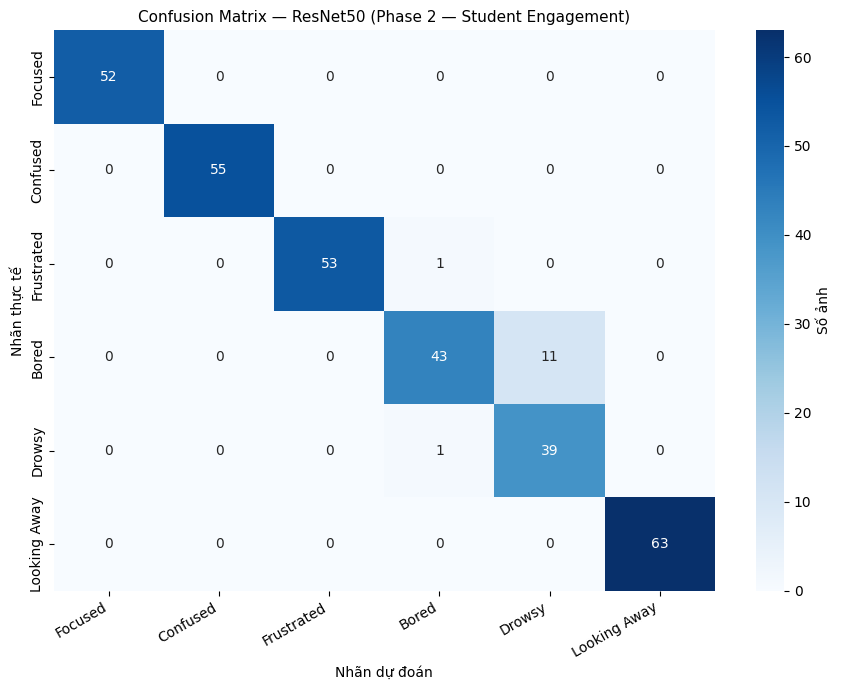

✅ Lưu: /content/drive/MyDrive/ProjectBTL/BTL/results/resnet50_confusion_matrix.png


In [24]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Predict trên test set
y_true, y_pred = [], []
for images, labels in test_student:
    preds = model_p2.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))
y_true, y_pred = np.array(y_true), np.array(y_pred)

label_names = ['Focused', 'Confused', 'Frustrated',
                'Bored', 'Drowsy', 'Looking Away']
report = classification_report(
    y_true, y_pred, target_names=label_names, output_dict=True
)
print(classification_report(y_true, y_pred, target_names=label_names))

# Lưu JSON
metrics = {
    'model': 'ResNet50',
    'phase1_best_val_acc': float(max(history_p1_unfreeze.history['val_accuracy'])),
    'phase2_accuracy':     float(report['accuracy']),
    'macro_f1':            float(report['macro avg']['f1-score']),
    'precision':           float(report['macro avg']['precision']),
    'recall':              float(report['macro avg']['recall']),
    'per_class_f1':        {n: float(report[n]['f1-score']) for n in label_names},
    'per_class_precision': {n: float(report[n]['precision']) for n in label_names},
    'per_class_recall':    {n: float(report[n]['recall']) for n in label_names},
}
with open(f'{RESULTS_DIR}/resnet50_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(f"\n✅ Lưu: {RESULTS_DIR}/resnet50_metrics.json")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            cbar_kws={'label': 'Số ảnh'})
plt.title('Confusion Matrix — ResNet50 (Phase 2 — Student Engagement)', fontsize=11)
plt.ylabel('Nhãn thực tế'); plt.xlabel('Nhãn dự đoán')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/resnet50_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Lưu: {RESULTS_DIR}/resnet50_confusion_matrix.png")

## Bonus — Training curves

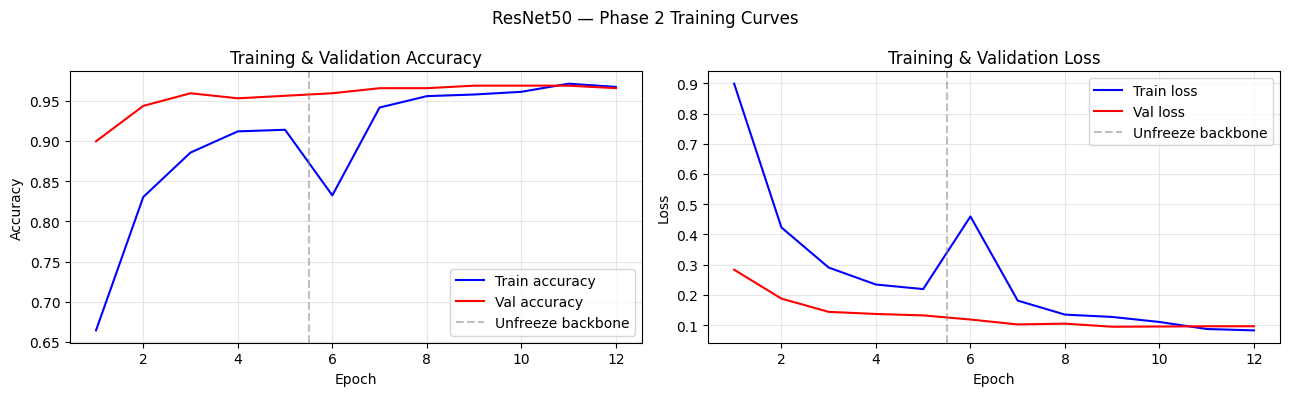

✅ Lưu: /content/drive/MyDrive/ProjectBTL/BTL/results/resnet50_training_curves.png


In [25]:
acc_train = (history_p2_freeze.history['accuracy'] +
             history_p2_unfreeze.history['accuracy'])
acc_val   = (history_p2_freeze.history['val_accuracy'] +
             history_p2_unfreeze.history['val_accuracy'])
loss_train = (history_p2_freeze.history['loss'] +
              history_p2_unfreeze.history['loss'])
loss_val   = (history_p2_freeze.history['val_loss'] +
              history_p2_unfreeze.history['val_loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs = range(1, len(acc_train) + 1)

axes[0].plot(epochs, acc_train, 'b-', label='Train accuracy')
axes[0].plot(epochs, acc_val,   'r-', label='Val accuracy')
axes[0].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Unfreeze backbone')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training & Validation Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, loss_train, 'b-', label='Train loss')
axes[1].plot(epochs, loss_val,   'r-', label='Val loss')
axes[1].axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Unfreeze backbone')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Training & Validation Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('ResNet50 — Phase 2 Training Curves', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/resnet50_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Lưu: {RESULTS_DIR}/resnet50_training_curves.png")

---
## ✅ Hoàn thành — Checklist nộp

| File | Vị trí |
|------|--------|
| ✅ `resnet50_phase1.h5` | `BTL/weights/` |
| ✅ `resnet50_phase2.h5` | `BTL/weights/` |
| ✅ `resnet50_metrics.json` | `BTL/results/` |
| ✅ `resnet50_confusion_matrix.png` | `BTL/results/` |
| ✅ `resnet50_training_curves.png` | `BTL/results/` |

**Việc Word còn lại (không có trong notebook):**
- Mục 3.4.2: mô tả kiến trúc ResNet50 (Residual/Skip Connection)
- Gửi số liệu accuracy + macro F1 cho Người 5